In [1]:
import pandas as pd

### `Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [2]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [3]:
df.stack(level=0, future_stack=True).swaplevel(0,1).sort_index(level=0)

avg_package  students
2019 cse delhi             1         2
         mumbai            0         0
     ece delhi             9        10
         mumbai            0         0
2020 cse delhi             3         4
         mumbai            0         0
     ece delhi            11        12
         mumbai            0         0
2021 cse delhi             5         6
         mumbai            0         0
     ece delhi            13        14
         mumbai            0         0
2022 cse delhi             7         8
         mumbai            0         0
     ece delhi            15        16
         mumbai            0         0

### `Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [4]:
confirm = pd.read_csv('datasets/time_series_covid19_confirmed_global.csv')

deaths = pd.read_csv("datasets/time_series_covid19_deaths_global.csv")

In [5]:
confirm.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229


In [6]:
deaths.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881


In [7]:
confirm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1081 entries, Province/State to 1/2/23
dtypes: float64(2), int64(1077), object(2)
memory usage: 2.4+ MB


In [8]:
deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1081 entries, Province/State to 1/2/23
dtypes: float64(2), int64(1077), object(2)
memory usage: 2.4+ MB


In [9]:
confirm = confirm.melt(id_vars = ["Province/State", "Country/Region", "Lat", "Long"], var_name='date', value_name='Cases')
deaths = deaths.melt(id_vars = ["Province/State","Country/Region", "Lat", "Long"], var_name='date', value_name='deaths')

In [10]:
confirm

,Province/State,Country/Region,Lat,Long,date,Cases
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,703228
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,535
311250,NaN,Yemen,15.552727,48.516388,1/2/23,11945
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,334661


In [11]:
deaths

,Province/State,Country/Region,Lat,Long,date,deaths
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,5708
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,0
311250,NaN,Yemen,15.552727,48.516388,1/2/23,2159
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,4024


In [12]:
df = confirm.merge(deaths, on=["Province/State", "Country/Region", "Lat", "Long", "date"])[["Province/State", "Country/Region", "date", "Cases", "deaths"]]
df

,Province/State,Country/Region,date,Cases,deaths
0,NaN,Afghanistan,1/22/20,0,0
1,NaN,Albania,1/22/20,0,0
2,NaN,Algeria,1/22/20,0,0
3,NaN,Andorra,1/22/20,0,0
4,NaN,Angola,1/22/20,0,0
...,...,...,...,...,...
311248,NaN,West Bank and Gaza,1/2/23,703228,5708
311249,NaN,Winter Olympics 2022,1/2/23,535,0
311250,NaN,Yemen,1/2/23,11945,2159
311251,NaN,Zambia,1/2/23,334661,4024


In [13]:
final_df = df.set_index(["Country/Region", "Province/State"]).sort_index()

final_df

date   Cases  deaths
Country/Region Province/State                          
Afghanistan    NaN              1/22/20       0       0
               NaN              1/23/20       0       0
               NaN              1/24/20       0       0
               NaN              1/25/20       0       0
               NaN              1/26/20       0       0
...                                 ...     ...     ...
Zimbabwe       NaN             12/29/22  259981    5637
               NaN             12/30/22  259981    5637
               NaN             12/31/22  259981    5637
               NaN               1/1/23  259981    5637
               NaN               1/2/23  259981    5637

[311253 rows x 3 columns]

### `Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [14]:
final_df

date   Cases  deaths
Country/Region Province/State                          
Afghanistan    NaN              1/22/20       0       0
               NaN              1/23/20       0       0
               NaN              1/24/20       0       0
               NaN              1/25/20       0       0
               NaN              1/26/20       0       0
...                                 ...     ...     ...
Zimbabwe       NaN             12/29/22  259981    5637
               NaN             12/30/22  259981    5637
               NaN             12/31/22  259981    5637
               NaN               1/1/23  259981    5637
               NaN               1/2/23  259981    5637

[311253 rows x 3 columns]

In [15]:
df = final_df.groupby("Country/Region").sum(numeric_only=True)


df['death_percentage']  = (df['deaths']/df['Cases'])*100

df = df.sort_values(by='death_percentage', ascending=False)

df.loc['India']

Cases               2.618192e+10
deaths              3.298920e+08
death_percentage    1.259999e+00
Name: India, dtype: float64

In [16]:
df = final_df.sort_values('date').groupby(['Country/Region', 'Province/State']).last()

df = df.groupby('Country/Region').sum()

df['death_percentage'] = (df['deaths'] / df['Cases']) * 100

df = df[['Cases','deaths', 'death_percentage']]

df.sort_values(by='death_percentage', ascending=False)

,Cases,deaths,death_percentage
Country/Region,,,
Canada,4224759,44599,1.055658
China,2605616,15331,0.588383
Netherlands,110414,640,0.579637
France,1180540,4517,0.382622
United Kingdom,217036,719,0.331281
Australia,10111728,14421,0.142617
Denmark,46629,49,0.105085
New Zealand,6462,1,0.015475


In [17]:
# The calculation is correct, but the dataset has inconsistencies like underreporting and different testing rates across countries.
# So, the death percentage (CFR) is not reliable for comparing countries directly and can give misleading results.

### `Q-4` : Make a dataframe for India from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.
Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [37]:
confirm = pd.read_csv('datasets/time_series_covid19_confirmed_global.csv')
deaths = pd.read_csv("datasets/time_series_covid19_deaths_global.csv")


confirm = confirm.melt(id_vars = ["Province/State", "Country/Region", "Lat", "Long"], var_name='date', value_name='Cases')
deaths = deaths.melt(id_vars = ["Province/State","Country/Region", "Lat", "Long"], var_name='date', value_name='deaths')

df = confirm.merge(deaths, on=["Province/State", "Country/Region", "Lat", "Long", "date"])[["Country/Region", "date", "Cases"]]
india_df = df[df['Country/Region'] == 'India']
india_df

,Country/Region,date,Cases
148,India,1/22/20,0
437,India,1/23/20,0
726,India,1/24/20,0
1015,India,1/25/20,0
1304,India,1/26/20,0
...,...,...,...
309956,India,12/29/22,44679382
310245,India,12/30/22,44679608
310534,India,12/31/22,44679873
310823,India,1/1/23,44680046


In [50]:
pd.to_datetime(india_df['date'], format='%m/%d/%y', errors='coerce')

# format='%m/%d/%y': telling pandas the actual formate of the data
# errors='coerce': Invalid dates → become NaT instead of crashing

india_df

,Country/Region,date,Cases,new_cases
99853,India,2021-01-01,10305788,10305788.0
205338,India,2022-01-01,34889132,24583344.0
310823,India,2023-01-01,44680046,9790914.0
102454,India,2021-01-10,10466595,-34213451.0
207939,India,2022-01-10,35875790,25409195.0
...,...,...,...,...
172103,India,2021-09-08,33139981,28769853.0
277588,India,2022-09-08,44484729,11344748.0
66907,India,2020-09-09,4465863,-40018866.0
172392,India,2021-09-09,33174954,28709091.0


In [51]:
india_df = india_df.sort_values(by='date')

In [52]:
india_df['new_cases'] = india_df['Cases'] - india_df['Cases'].shift(1)
india_df

,Country/Region,date,Cases,new_cases
148,India,2020-01-22,0,NaN
437,India,2020-01-23,0,0.0
726,India,2020-01-24,0,0.0
1015,India,2020-01-25,0,0.0
1304,India,2020-01-26,0,0.0
...,...,...,...,...
309956,India,2022-12-29,44679382,243.0
310245,India,2022-12-30,44679608,226.0
310534,India,2022-12-31,44679873,265.0
310823,India,2023-01-01,44680046,173.0


In [53]:
india_df['new_cases'].fillna(india_df['Cases'], inplace=True)
india_df

,Country/Region,date,Cases,new_cases
148,India,2020-01-22,0,0.0
437,India,2020-01-23,0,0.0
726,India,2020-01-24,0,0.0
1015,India,2020-01-25,0,0.0
1304,India,2020-01-26,0,0.0
...,...,...,...,...
309956,India,2022-12-29,44679382,243.0
310245,India,2022-12-30,44679608,226.0
310534,India,2022-12-31,44679873,265.0
310823,India,2023-01-01,44680046,173.0


In [59]:
#### How shift works

# shift() moves data up or down without changing index

s = pd.Series([100, 150, 200])
print(s)



0    100
1    150
2    200
dtype: int64


In [60]:
s.shift(1)

# Each value moved down by 1 position
# First value --> becomes NaN
# Previous value comes into current row

0      NaN
1    100.0
2    150.0
dtype: float64

In [61]:
s.shift(-1)

0    150.0
1    200.0
2      NaN
dtype: float64

### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [43]:
df = pd.read_csv('datasets/List of most-polluted cities by particulate matter concentration.csv')
df = df.set_index(['Country', 'City/Town']).sort_index()
df

Unnamed: 0  Position  Year  PM2.5 Temporal coverage  \
Country City/Town                                                               
Bahrain Hamad Town                79        80  2012     66               NaN   
        Hidd                     279       280  2012     41               NaN   
        Ma'ameer                  87        88  2012     64               NaN   
        Manama                    94        95  2016     63        50% -< 75%   
        Nabih Saleh              115       116  2012     58               NaN   
...                              ...       ...   ...    ...               ...   
Turkey  Sakarya                  393       394  2016     32              >75%   
        Sivas                    499       500  2016     27              >75%   
Uganda  Kampala                   14        15  2013    104               NaN   
Vietnam Hanoi                    213       214  2016     48              >75%   
        Ho Chi Minh City         278       279  2016     42              >75%   

                          PM10 Temporal coverage.1  Database version (year)  
Country City/Town                                                            
Bahrain Hamad Town         318                 NaN                     2016  
        Hidd               178                 NaN                     2016  
        Ma'ameer           257                 NaN                     2016  
        Manama             154                 NaN                     2018  
        Nabih Saleh        244                 NaN                     2016  
...                        ...                 ...                      ...  
Turkey  Sakarya             60                >75%                     2018  
        Sivas               56                >75%                     2018  
Uganda  Kampala            170                 NaN                     2016  
Vietnam Hanoi              102                 NaN                     2018  
        Ho Chi Minh City    90                 NaN                     2018  

[500 rows x 8 columns]

In [44]:
# 1. Find out the name of the city of India which is most poluted based on PM10.

df.loc['India'].sort_values('PM10', ascending=False).head(1)

,Unnamed: 0,Position,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
City/Town,,,,,,,,
Kanpur,0,1,2016,173,>75%,319,NaN,2018


In [45]:
# 2. Find out the name of the city of India which has minumum pollution level based on PM10.

df.loc['India'].sort_values('PM10').head(1)

,Unnamed: 0,Position,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
City/Town,,,,,,,,
Aizawl,483,484,2016,27,NaN,44,NaN,2018


In [46]:
# 3. Do same operations (like 1 and 2) with the country China.

# Max
df.loc['China'].sort_values('PM10', ascending=False).head(1)

# Min
df.loc['China'].sort_values('PM10').head(1)

,Unnamed: 0,Position,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
City/Town,,,,,,,,
Anshun,476,477,2016,27,NaN,38,NaN,2018


<Axes: ylabel='PM10'>

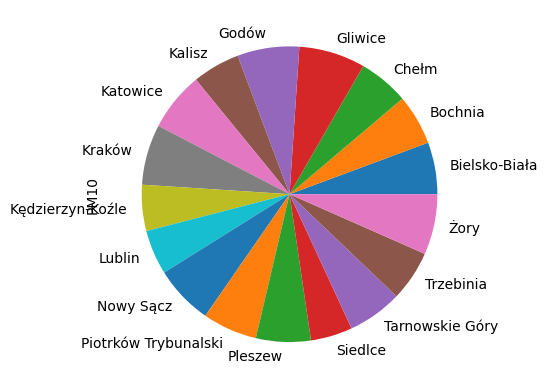

In [47]:
# 4. Make a pie chart based on the column "PM10" of the country Poland.

df.loc['Poland']['PM10'].plot(kind='pie')

<Axes: xlabel='Country,City/Town'>

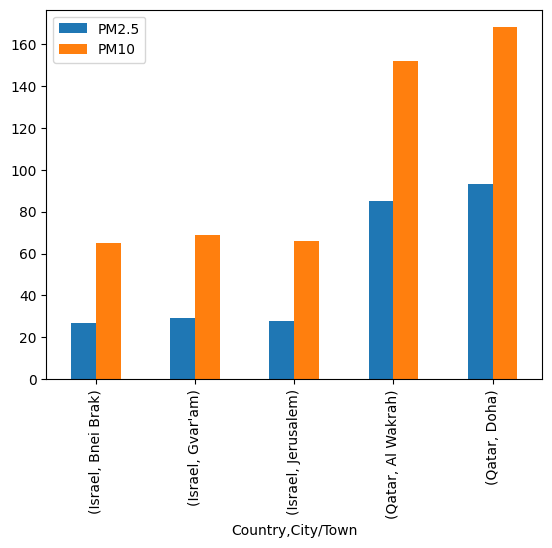

In [48]:
# 5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar


bar_df = df.loc[['Israel', 'Qatar']][['PM2.5', 'PM10']]

bar_df.plot(kind='bar')

In [51]:
# 6. Convert this MultiIndex DataFrame to Series by retaining the informations.

series_df = df.stack()

series_df

Country  City/Town                                
Bahrain  Hamad Town        Unnamed: 0                   79
                           Position                     80
                           Year                       2012
                           PM2.5                        66
                           PM10                        318
                                                      ... 
Vietnam  Ho Chi Minh City  Year                       2016
                           PM2.5                        42
                           Temporal coverage          >75%
                           PM10                         90
                           Database version (year)    2018
Length: 3138, dtype: object